### **Lunar Lander DDQN with PER TORCH**

There is no Gradient Clipping in this example. Would you improve with Gradient Clipping?
<br>
In this version the agent has been created as a class making the code more compact <br>
This DDQN Class can be used with other environments <br>
 <br>
Try to make it faster by doing some hyperparameter optimization  <br>
Try to explore less. Does it accelerates convergence?  <br>
Increasing the ```ROLLING_WINDOW``` value will gnerate slower agent convergence but the Agent behavior will be more consistent <br>

An issue you may find is a lander that hovers forever. This happens because it has been programmed with infinite fuel. You can see it in this execution in the lines that are marked as ```Terminated=False```. This confuses the training because it does not reach the objective or termination. Without modifying the environment, there are a couple of things that can be done to ameliorate this behavior <br>

1. **Limit number of steps** In this case we are limiting the number of steps to 1200, if you don't limit it sometimes it goes up to thousands of steps, and this is a waste of time
2. **Increase gravity** The default gravity in this environment is -10.0, you can increase it up to -12.0, increasing it you'll have a faster descent and hovering becomes more difficult ```env = gym.make("LunarLander-v3", gravity=11.0)```

In [1]:
import os
import random
import gymnasium as gym
import time
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
import time

import sys
sys.stderr = open('err.txt', 'w')


In [2]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (built):", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"    Compute capability: {torch.cuda.get_device_capability(i)}")
        print(f"    Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")

    # Quick sanity check: actually run something on the GPU
    x = torch.randn(1000, 1000, device="cuda")
    y = x @ x
    print("Matmul on GPU OK, result shape:", y.shape)
else:
    print("No GPU visible to PyTorch.")

PyTorch version: 2.11.0+cu130
CUDA available: True
CUDA version (built): 13.0
Device count: 1
  GPU 0: NVIDIA GB10
    Compute capability: (12, 1)
    Memory: 130.6 GB
Matmul on GPU OK, result shape: torch.Size([1000, 1000])


#### **Hyperparameters**

In [3]:

MAX_EPISODES = 2000
ROLLING_WINDOW = 40
MEMORY_SIZE = 100_000
MAX_STEPS = 400

gamma = 0.99                         # discount rate
epsilon = 1.0                        # exploration rate
epsilon_min = 0.05
epsilon_decay = 0.995
learning_rate = 5e-4
batch_size = 64
solved_threshold = 200
REFRESH_TARGET_NET = 1
TAU = 0.005
UPDATE_WEIGHTS = 'soft'       # choose 'soft' or 'hard'
GRADIENT_CLIP = 7.0
RANDOM_SEED = 145
WARMUP_STEPS = 1000


verb = 0                             # to see traces (verbosity)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)         # you sample with np.random.choice — seed this too
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [4]:
# Environment setup
env = gym.make('LunarLander-v3')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

In [5]:
class Q_Network(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.out = nn.Linear(32, action_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.out(x)

In [6]:
class Agent_DDQN():
    def __init__(self, states, actions, alpha, gamma, epsilon):
        self.nS = states
        self.nA = actions
        self.replay_buffer = deque([], maxlen=MEMORY_SIZE)
        self.priorities = deque([], maxlen=MEMORY_SIZE)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        # 1. Initialize TWO networks
        self.model = self.build_NN()
        self.target_model = self.build_NN()
        
        # Sync them initially
        self.update_target_network(update_type='hard')
        
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
#        self.loss_fn = nn.MSELoss(reduction='none')
        self.loss_fn = nn.SmoothL1Loss(reduction='none')
        self.loss = []
        self.step_count = 0
        self.priority_alpha = 0.3
        self.priority_beta = 0.4
        self.priority_beta_increment = 1e-4
        self.priority_epsilon = 0.01
        self.priority_upper = 1.0

    def build_NN(self):
        return Q_Network(self.nS, self.nA).to(device)

    def update_target_network(self, update_type=UPDATE_WEIGHTS, tau=TAU):
        if update_type == 'hard':
            self.target_model.load_state_dict(self.model.state_dict())
        elif update_type == 'soft':
            for target_param, model_param in zip(self.target_model.parameters(), self.model.parameters()):
                target_param.data.copy_(tau * model_param.data + (1.0 - tau) * target_param.data)
        else:
            raise ValueError("UPDATE_WEIGHTS must be 'soft' or 'hard'")

    def action(self, state):
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device)
        self.model.eval()
        with torch.no_grad():
            action_vals = self.model(state_tensor)
        self.model.train()
        return torch.argmax(action_vals, dim=-1).item()
    
    def random_action(self):
        return random.randrange(self.nA)
    
    def store_experience(self, state, action, reward, next_state, done):
        self.replay_buffer.append((state, action, reward, next_state, done))
        max_priority = max(self.priorities, default=1.0)
        self.priorities.append(max_priority)

    def sample_experiences(self, batch_size):
        priorities = np.array(self.priorities, dtype=np.float32)
        scaled_priorities = priorities ** self.priority_alpha
        probabilities = scaled_priorities / scaled_priorities.sum()
        indices = np.random.choice(len(self.replay_buffer), batch_size, replace=False, p=probabilities)
        weights = (len(self.replay_buffer) * probabilities[indices]) ** (-self.priority_beta)
        
        weights = weights / weights.max()
        self.priority_beta = min(1.0, self.priority_beta + self.priority_beta_increment)
        batch = [self.replay_buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            indices,
            weights.astype(np.float32),
            np.vstack(states),
            np.array(actions),
            np.array(rewards),
            np.vstack(next_states),
            np.array(dones, dtype=np.float32)
        )

    def update_priorities(self, indices, td_errors):
        for index, td_error in zip(indices, td_errors):
            priority = abs(td_error) + self.priority_epsilon
            self.priorities[index] = min(priority, self.priority_upper)
    
    def PER_experience_replay(self, batch_size, epsilon):
        if len(self.replay_buffer) < max(batch_size, WARMUP_STEPS):
            return
        
        self.step_count += 1
        indices, weights, states, actions, rewards, next_states, dones = self.sample_experiences(batch_size)
    
        states_tensor = torch.as_tensor(states, dtype=torch.float32, device=device)
        actions_tensor = torch.as_tensor(actions, dtype=torch.long, device=device)
        rewards_tensor = torch.as_tensor(rewards, dtype=torch.float32, device=device)
        next_states_tensor = torch.as_tensor(next_states, dtype=torch.float32, device=device)
        dones_tensor = torch.as_tensor(dones, dtype=torch.float32, device=device)
        weights_tensor = torch.as_tensor(weights, dtype=torch.float32, device=device)
    
        q_values_taken = self.model(states_tensor).gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_actions = self.model(next_states_tensor).argmax(dim=1)
            next_q = self.target_model(next_states_tensor).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            targets = rewards_tensor + self.gamma * next_q * (1 - dones_tensor)
    
        # TD errors for priority updates (computed BEFORE the optimizer step)
        td_errors = (targets - q_values_taken).detach().abs().cpu().numpy()
        self.update_priorities(indices, td_errors)
    
        # Weighted loss — needs reduction='none' on the loss_fn, which you already set
        losses = self.loss_fn(q_values_taken, targets)
        loss = (losses * weights_tensor).mean()
    
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=GRADIENT_CLIP)
        self.optimizer.step()
        self.loss.append(loss.item())
    
        if self.step_count % REFRESH_TARGET_NET == 0:
            self.update_target_network(update_type=UPDATE_WEIGHTS)

In [7]:
# Support function
def select_action_greedy(state, agent_DDQN):                                    
    if np.random.rand() <= epsilon:
        return agent_DDQN.random_action()
    return agent_DDQN.action(state) 

#### **Main Loop**

In [8]:
env = gym.make('LunarLander-v3')
_, _ = env.reset(seed=RANDOM_SEED)
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

agent = Agent_DDQN(state_size, action_size, learning_rate, gamma, epsilon)

In [9]:
%%time
rewards_per_episode= []
start_time = time.time()

done = False
rolling_avg = 0
rolling_avg_rewards = []



for e in range(MAX_EPISODES):                           # Should be While True, however we limit number of eps
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    
    for step in range(MAX_STEPS):
            
        action = select_action_greedy(state, agent)
        next_state, reward, terminated, truncated , _ = env.step(action)
                    
        next_state = np.reshape(next_state, [1, state_size])
        done_for_buffer = terminated and not truncated
        agent.store_experience(state, action, reward, next_state, done_for_buffer)
        state = next_state
        total_reward = total_reward + reward
        if terminated or truncated:
            break
            
        if step % 1 == 0:
            agent.PER_experience_replay(batch_size, epsilon)           # only train every 4 steps as in the original DDQN paper
            
    epsilon = max(epsilon_min, epsilon * epsilon_decay)            # decay epsilon
    
    rewards_per_episode.append(total_reward)
    rolling_avg = np.mean(rewards_per_episode[-ROLLING_WINDOW:])   # append rewards
    rolling_avg_rewards.append(rolling_avg)
    print(f"Episode: {e+1:3}/{MAX_EPISODES}, Reward: {total_reward:+7.2f}, "
          f"Epsilon: {epsilon:.2f}, Rolling Avg: {rolling_avg:7.2f}, Steps: {step:4} Terminated: {terminated} ")

            
    # Check if environment is solved
    if rolling_avg >= solved_threshold:
        print(f"Environment solved in {e+1} episodes!")
        break

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")

Episode:   1/2000, Reward: -243.33, Epsilon: 0.99, Rolling Avg: -243.33, Steps:  117 Terminated: True 
Episode:   2/2000, Reward: -135.98, Epsilon: 0.99, Rolling Avg: -189.66, Steps:   76 Terminated: True 
Episode:   3/2000, Reward:  -19.70, Epsilon: 0.99, Rolling Avg: -133.00, Steps:  106 Terminated: True 
Episode:   4/2000, Reward: -179.44, Epsilon: 0.98, Rolling Avg: -144.61, Steps:   79 Terminated: True 
Episode:   5/2000, Reward: -105.64, Epsilon: 0.98, Rolling Avg: -136.82, Steps:   82 Terminated: True 
Episode:   6/2000, Reward: -263.44, Epsilon: 0.97, Rolling Avg: -157.92, Steps:   71 Terminated: True 
Episode:   7/2000, Reward: -100.66, Epsilon: 0.97, Rolling Avg: -149.74, Steps:  101 Terminated: True 
Episode:   8/2000, Reward: -167.48, Epsilon: 0.96, Rolling Avg: -151.96, Steps:  112 Terminated: True 
Episode:   9/2000, Reward:  -62.38, Epsilon: 0.96, Rolling Avg: -142.01, Steps:   80 Terminated: True 
Episode:  10/2000, Reward:  -72.06, Epsilon: 0.95, Rolling Avg: -135.01, 

#### **Learning Plot and Episode Rewards**

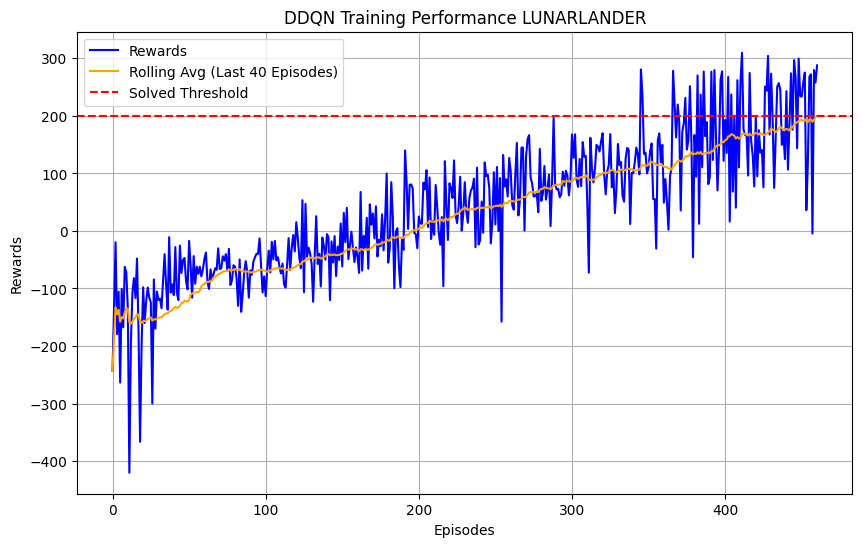

In [10]:
# Plot rewards with rolling average

plt.figure(figsize=(10, 6))
plt.plot(rewards_per_episode, label='Rewards', color='blue')
plt.plot(rolling_avg_rewards, label='Rolling Avg (Last '+str(ROLLING_WINDOW) +' Episodes)', color='orange')
plt.axhline(y=solved_threshold, color='red', linestyle='--', label='Solved Threshold')
plt.title('DDQN Training Performance LUNARLANDER with PER')
plt.xlabel('Episodes')
plt.ylabel('Rewards')
plt.legend()
plt.grid()
plt.show()

#### **Simulation - Testing 10 episodes with the DDQN Network**

In [11]:
# Testing for 10 episodes
start_time = time.time()

for e_test in range(10):  # Run 10 test episodes
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    
    steps = 0
    while True:
        # Use the trained model for testing
        action = agent.action(state)  # Estimate action values


        next_state, reward, done, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])
        total_reward += reward
        state = next_state
        steps = steps + 1
        if done or truncated:
            print(f"Test Episode: {e_test + 1:2}/10, Reward: {total_reward:.2f}, Steps: {steps:3}")
            break

end_time = time.time()
testing_duration = (end_time - start_time) / 60  # Convert to minutes
print(f"Testing completed in {testing_duration:.2f} minutes")

Test Episode:  1/10, Reward: 246.26, Steps: 191
Test Episode:  2/10, Reward: 273.37, Steps: 299
Test Episode:  3/10, Reward: 257.04, Steps: 239
Test Episode:  4/10, Reward: 274.06, Steps: 184
Test Episode:  5/10, Reward: 234.98, Steps: 397
Test Episode:  6/10, Reward: 273.37, Steps: 219
Test Episode:  7/10, Reward: 247.17, Steps: 241
Test Episode:  8/10, Reward: 258.95, Steps: 370
Test Episode:  9/10, Reward: 279.50, Steps: 283
Test Episode: 10/10, Reward: 142.51, Steps: 1000
Testing completed in 0.01 minutes


#### **Rendering 1 episode**

In [12]:
# Test the trained agent with video rendering
# This code is useful if you are using colab otherwise use render_mode='human'
env = gym.make(('LunarLander-v3'), render_mode='rgb_array')  # Enable RGB rendering
frames = []  # Store frames for visualization

# Render a single test episode
state, _ = env.reset()
state = np.reshape(state, [1, state_size])
tot_rewards = 0

while True:
    # Use the trained model for action
    action = agent.action(state)            # Estimate action value

    next_state, reward, done, truncated, _ = env.step(action)
    frames.append(env.render())                  # Save frame for rendering later
    next_state = np.reshape(next_state, [1, state_size])
    tot_rewards += reward
    state = next_state

    if done or truncated:
        print(f"Rendered Test Episode Reward: {tot_rewards:.2f}")
        break

env.close()

# Save the rendered episode as a GIF
def save_frames_as_gif(frames, path='./', filename='LUNARLANDER_Agent_DDQN.gif'):
    images = [Image.fromarray(frame) for frame in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(gif_path, save_all=True, append_images=images[1:], duration=50, loop=0)
    print(f"Saved GIF to: {gif_path}")

save_frames_as_gif(frames, filename='LUNARLANDER_Agent_DDQN.gif')


Rendered Test Episode Reward: 253.34
Saved GIF to: ./LUNARLANDER_Agent_DDQN.gif


In [13]:
import session_info
session_info.show(html=False)

-----
PIL                 12.1.0
gymnasium           1.2.2
matplotlib          3.10.8
numpy               2.4.2
session_info        v1.0.1
torch               2.11.0+cu130
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
-----
Python 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Linux-6.17.0-1018-nvidia-aarch64-with-glibc2.39
-----
Session information updated at 2026-05-15 20:10
